## **Advanced Imputation Techniques**

This notebook covers three strategies for handling missing data: 
1. Random Sample Imputation
2. creating a Missing Indicator
3. Automatically selecting the best imputation strategy using GridSearchCV

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import MissingIndicator, SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')

### **1. Random Sample Imputation**

Random sample imputation works for both categorical and numerical data. It replaces missing values with random observations drawn from the available data

**Numerical Data (Titanic Dataset)**

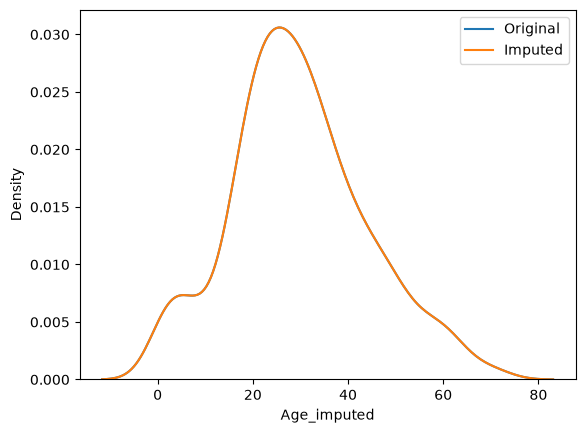

Original variable variance:  204.3495133904614
Variance after random imputation:  204.3495133904614


In [5]:
df = pd.read_csv('docs/Lecture-025-train.csv', usecols=['Age', 'Fare', 'Survived'])
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Create copies for imputation
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

# Randomly sample from non-null values to fill nulls
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

# Visualize the effect on the distribution
sns.distplot(X_train['Age'], label='Original', hist=False)
sns.distplot(X_train['Age_imputed'], label='Imputed', hist=False)
plt.legend()
plt.show()

print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

**Categorical Data (House Prices Dataset)**

We can apply the exact same random sampling logic to categorical attributes

In [6]:
data = pd.read_csv('docs/Lecture-025-house-train.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])
X_cat = data
y_cat = data['SalePrice']

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X_cat, y_cat, test_size=0.2, random_state=2)

X_train_cat['GarageQual_imputed'] = X_train_cat['GarageQual']
X_train_cat['FireplaceQu_imputed'] = X_train_cat['FireplaceQu']

# Impute categorical features
X_train_cat['GarageQual_imputed'][X_train_cat['GarageQual_imputed'].isnull()] = X_train_cat['GarageQual'].dropna().sample(X_train_cat['GarageQual'].isnull().sum()).values
X_train_cat['FireplaceQu_imputed'][X_train_cat['FireplaceQu_imputed'].isnull()] = X_train_cat['FireplaceQu'].dropna().sample(X_train_cat['FireplaceQu'].isnull().sum()).values

temp = pd.concat([
    X_train_cat['GarageQual'].value_counts() / len(X_train_cat['GarageQual'].dropna()),
    X_train_cat['GarageQual_imputed'].value_counts() / len(X_train_cat)
], axis=1)
temp.columns = ['original', 'imputed']
print("GarageQual Proportions:\n", temp)

GarageQual Proportions:
     original   imputed
TA  0.951043  0.898116
Fa  0.037171  0.035103
Gd  0.009973  0.009418
Po  0.000907  0.000856
Ex  0.000907  0.000856


### **2. Missing Indicator**

A missing indicator explicitly flags rows where data was missing. This allows the model to capture predictive patterns tied directly to the missingness of the data

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Baseline: SimpleImputer without indicator
si = SimpleImputer()
X_train_trf = si.fit_transform(X_train)
X_test_trf = si.transform(X_test)

clf = LogisticRegression()
clf.fit(X_train_trf, y_train)
print("Accuracy without indicator:", accuracy_score(y_test, clf.predict(X_test_trf)))

# Improvement: SimpleImputer with indicator
si_ind = SimpleImputer(add_indicator=True)
X_train_trf2 = si_ind.fit_transform(X_train)
X_test_trf2 = si_ind.transform(X_test)

clf.fit(X_train_trf2, y_train)
print("Accuracy with indicator:", accuracy_score(y_test, clf.predict(X_test_trf2)))

Accuracy without indicator: 0.6145251396648045
Accuracy with indicator: 0.6312849162011173


### **3. Automatically Selecting Imputation Values**

We can treat the imputation strategy as a hyperparameter and optimize it using `GridSearchCV`[cite: 5].

In [8]:
df_full = pd.read_csv('docs/Lecture-025-train.csv')
df_full.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)
X_full = df_full.drop(columns=['Survived'])
y_full = df_full['Survived']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_full, test_size=0.2, random_state=2)

# 1. Define preprocessors
numerical_features = ['Age', 'Fare']
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = ['Embarked', 'Sex']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

# 2. Build pipeline
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# 3. Configure grid search
param_grid = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    'preprocessor__cat__imputer__strategy': ['most_frequent', 'constant'],
    'classifier__C': [0.1, 1.0, 10, 100]
}

grid_search = GridSearchCV(clf_pipeline, param_grid, cv=10)
grid_search.fit(X_train_full, y_train_full)

print("Best params:", grid_search.best_params_)
print(f"Internal CV score: {grid_search.best_score_:.3f}")

Best params: {'classifier__C': 1.0, 'preprocessor__cat__imputer__strategy': 'most_frequent', 'preprocessor__num__imputer__strategy': 'mean'}
Internal CV score: 0.788
